In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

In [2]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

In [3]:
BASE_DIRS = {
    "baseline": "results",
    "xavier": "results_no_graphnorm",
    "graphnorm_xavier": "results_with_graphnorm",
}
models = ["GCN", "GAT", "SAGE"]

all_training = []
all_test_td = []
all_test_ti = []

# === Load everything ===
for cfg_name, cfg_dir in BASE_DIRS.items():
    for model in models:
        # Training results (JSON)
        tr_path = os.path.join(cfg_dir, model, f"{model}_training_results.json")
        if os.path.exists(tr_path):
            with open(tr_path) as f:
                tr_json = json.load(f)
            
            # Flatten study dataframe
            study_df = pd.DataFrame(tr_json["Study"])
            study_df["Model"] = model
            study_df["Config"] = cfg_name
            all_training.append(study_df)
        
        # TD (test results with Precision/Recall/F1)
        td_path = os.path.join(cfg_dir, model, "results_TD.csv")
        if os.path.exists(td_path):
            td_df = pd.read_csv(td_path)
            td_df["Model"] = model
            td_df["Config"] = cfg_name
            all_test_td.append(td_df)
        
        # TI (test results with AUC/AP)
        ti_path = os.path.join(cfg_dir, model, "results_TI.csv")
        if os.path.exists(ti_path):
            ti_df = pd.read_csv(ti_path)
            ti_df["Model"] = model
            ti_df["Config"] = cfg_name
            all_test_ti.append(ti_df)

# Combine
df_training = pd.concat(all_training, ignore_index=True) if all_training else pd.DataFrame()
df_td = pd.concat(all_test_td, ignore_index=True) if all_test_td else pd.DataFrame()
df_ti = pd.concat(all_test_ti, ignore_index=True) if all_test_ti else pd.DataFrame()

print("Training shape:", df_training.shape)
print("TD shape:", df_td.shape)
print("TI shape:", df_ti.shape)


Training shape: (900, 17)
TD shape: (900, 11)
TI shape: (900, 4)


In [4]:
# ---------- helper functions ----------
def parse_history(entry):
    """Return dict from user_attrs_history cell; handle dict or string or NaN."""
    if pd.isna(entry):
        return {}
    if isinstance(entry, dict):
        return entry
    try:
        return ast.literal_eval(entry)
    except Exception:
        # sometimes it's like "{'train_loss': [..], 'val_score': [..]}"
        try:
            return json.loads(entry)
        except Exception:
            return {}

def pad_and_stack(list_of_lists, dtype=float):
    """Pad lists to same length with nan and return 2D numpy array (n_lists, max_len)."""
    if len(list_of_lists) == 0:
        return np.empty((0,0))
    max_len = max(len(l) for l in list_of_lists)
    arr = np.full((len(list_of_lists), max_len), np.nan, dtype=dtype)
    for i, l in enumerate(list_of_lists):
        arr[i, :len(l)] = l
    return arr

def mean_std_from_histories(histories, key):
    """histories is series/list of user_attrs_history; key like 'train_loss' or 'val_score'"""
    lists = []
    for h in histories:
        h2 = parse_history(h)
        arr = h2.get(key)
        if arr is not None:
            # some values maybe lists-of-floats or strings -> try to coerce
            lists.append([float(x) for x in arr])
    if not lists:
        return None, None, 0
    arr2 = pad_and_stack(lists)
    mean = np.nanmean(arr2, axis=0)
    std = np.nanstd(arr2, axis=0)
    return mean, std, arr2.shape[1]


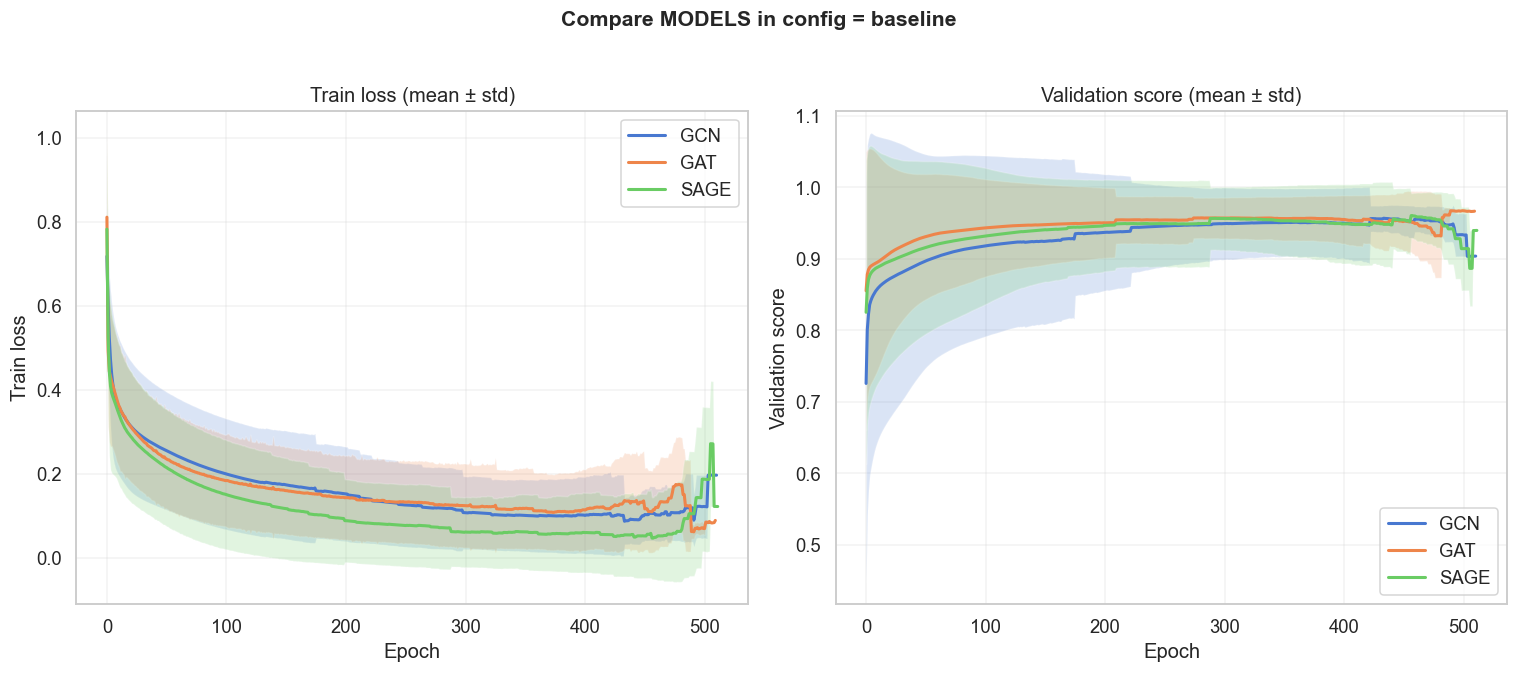

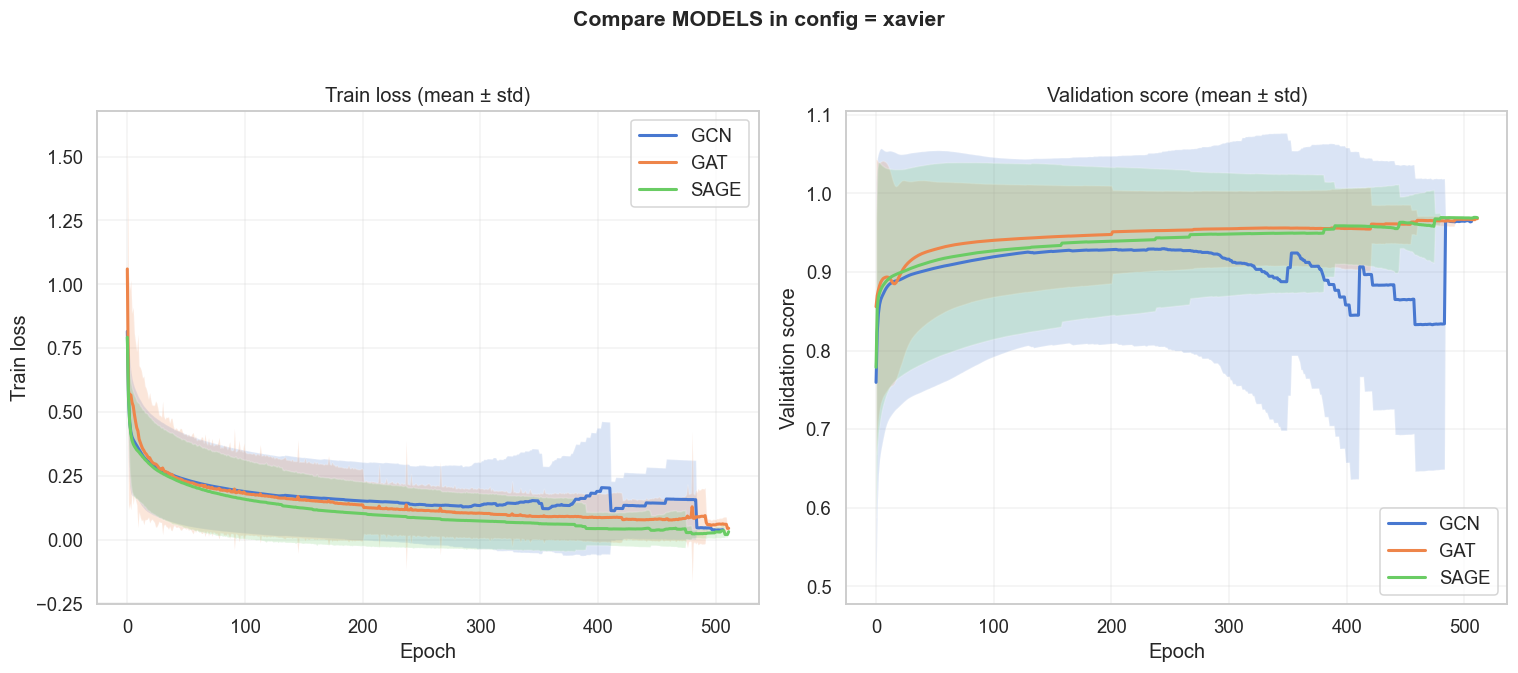

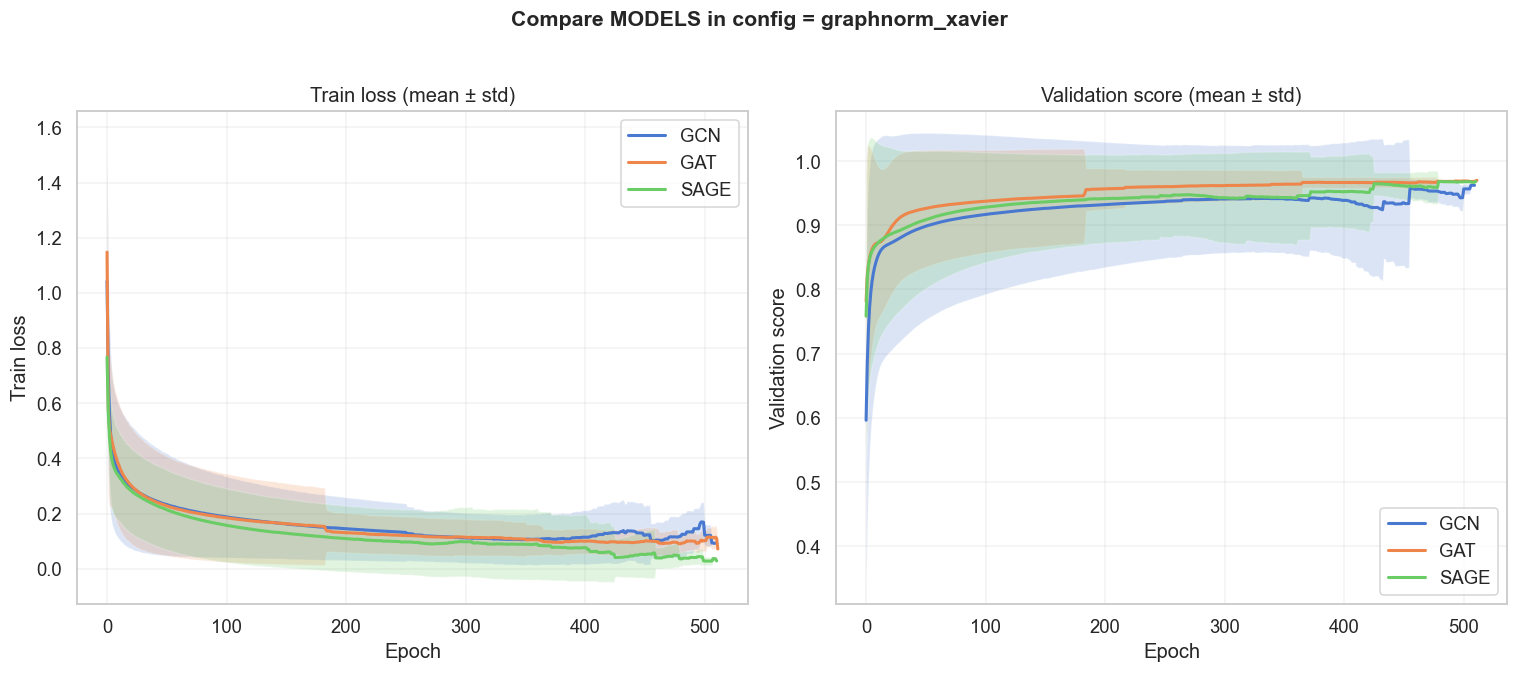

In [5]:
# ---------- 1) Compare 3 models within each config: Loss & Val curve ----------
configs = df_training["Config"].unique().tolist()
models = df_training["Model"].unique().tolist()

for cfg in configs:
    plt.figure(figsize=(14,6))
    plt.suptitle(f"Compare MODELS in config = {cfg}", y=1.02, fontsize=14, weight="bold")

    # TRAIN LOSS subplot
    ax0 = plt.subplot(1,2,1)
    for m in models:
        subset = df_training[(df_training["Config"]==cfg) & (df_training["Model"]==m)]
        mean, std, length = mean_std_from_histories(subset["user_attrs_history"].tolist(), "train_loss")
        if mean is None: 
            continue
        epochs = np.arange(len(mean))
        ax0.plot(epochs, mean, label=m, linewidth=2)
        ax0.fill_between(epochs, mean-std, mean+std, alpha=0.2)
    ax0.set_xlabel("Epoch")
    ax0.set_ylabel("Train loss")
    ax0.set_title("Train loss (mean ± std)")
    ax0.legend()
    ax0.grid(alpha=0.25)

    # VAL SCORE subplot (could be val_score or val_auc or val_loss: try val_score, fallback val_auc)
    ax1 = plt.subplot(1,2,2)
    for m in models:
        subset = df_training[(df_training["Config"]==cfg) & (df_training["Model"]==m)]
        # try val_score, val_auc, val_loss in that order
        mean, std, length = mean_std_from_histories(subset["user_attrs_history"].tolist(), "val_score")
        if mean is None:
            mean, std, length = mean_std_from_histories(subset["user_attrs_history"].tolist(), "val_auc")
        if mean is None:
            mean, std, length = mean_std_from_histories(subset["user_attrs_history"].tolist(), "val_loss")
        if mean is None:
            continue
        epochs = np.arange(len(mean))
        ax1.plot(epochs, mean, label=m, linewidth=2)
        ax1.fill_between(epochs, mean-std, mean+std, alpha=0.2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Validation score")
    ax1.set_title("Validation score (mean ± std)")
    ax1.legend()
    ax1.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

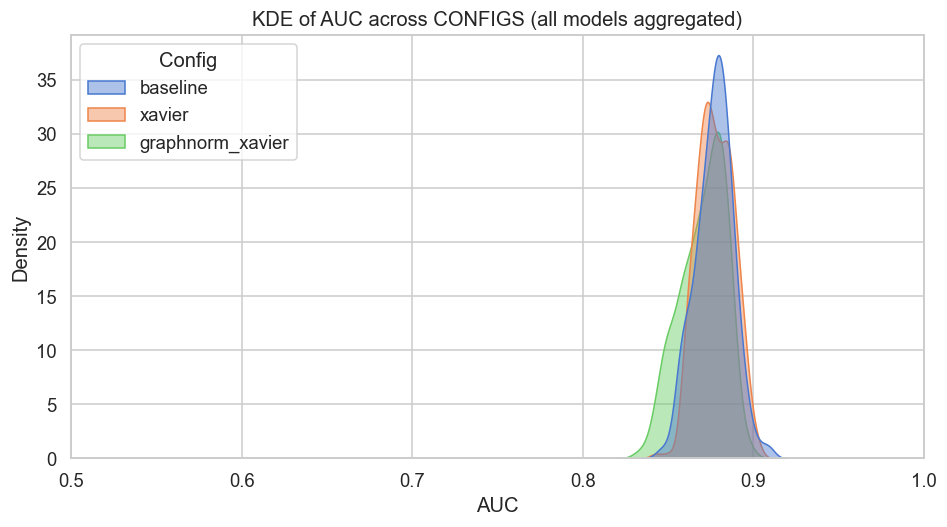

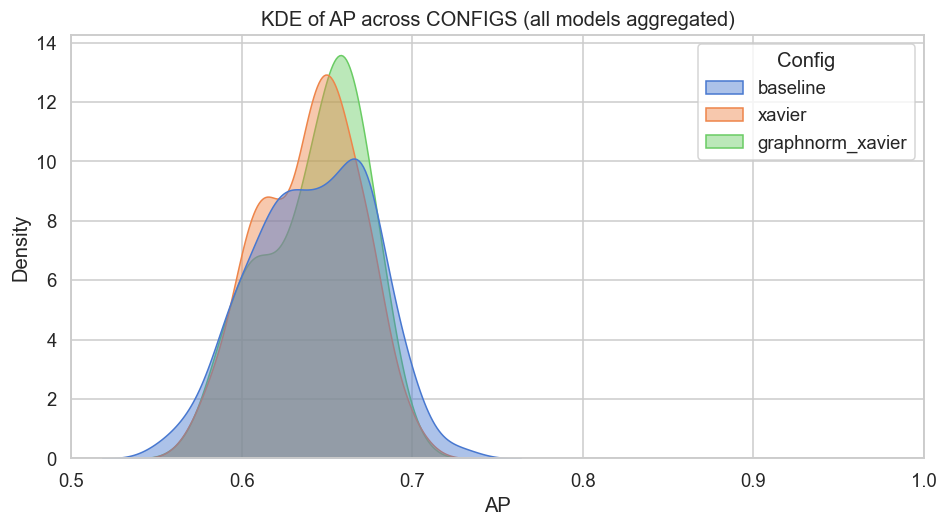

In [6]:
# ---------- 2) Compare metrics across configs (per config + global) ----------
# a) KDE of AUC & AP per config (all models combined)
for metric in ["AUC", "AP"]:
    plt.figure(figsize=(10,5))
    sns.kdeplot(data=df_ti, x=metric, hue="Config", fill=True, common_norm=False, alpha=0.45)
    plt.title(f"KDE of {metric} across CONFIGS (all models aggregated)")
    plt.xlabel(metric)
    plt.xlim(0.5,1.0)
    plt.show()

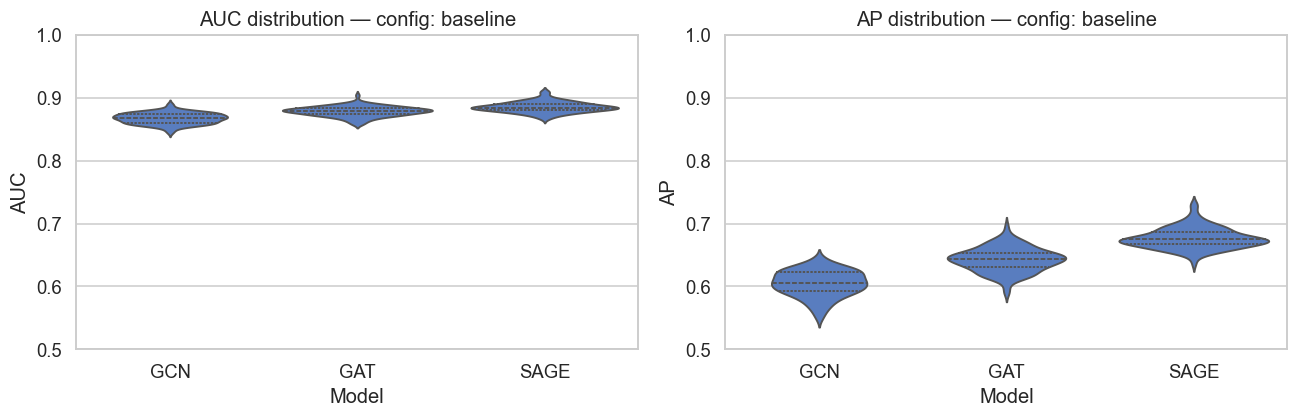

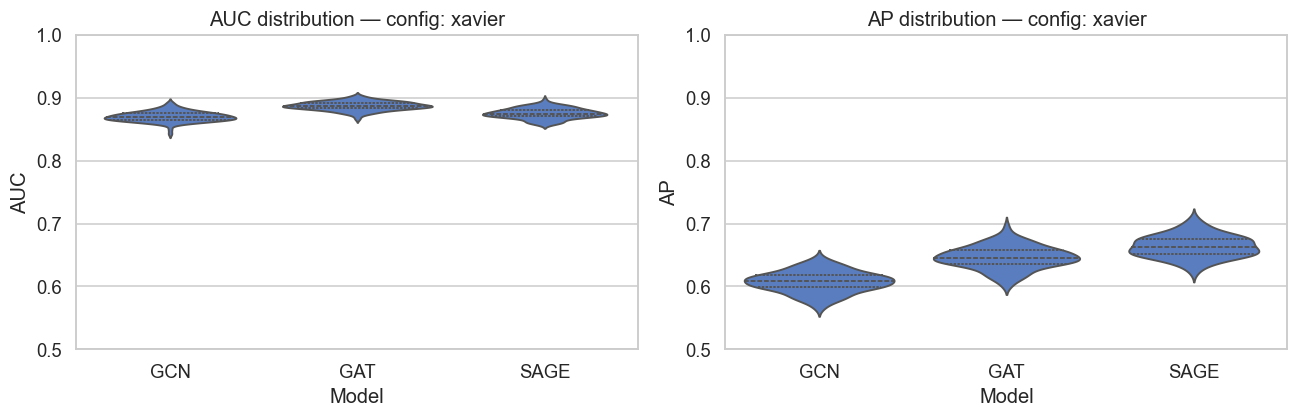

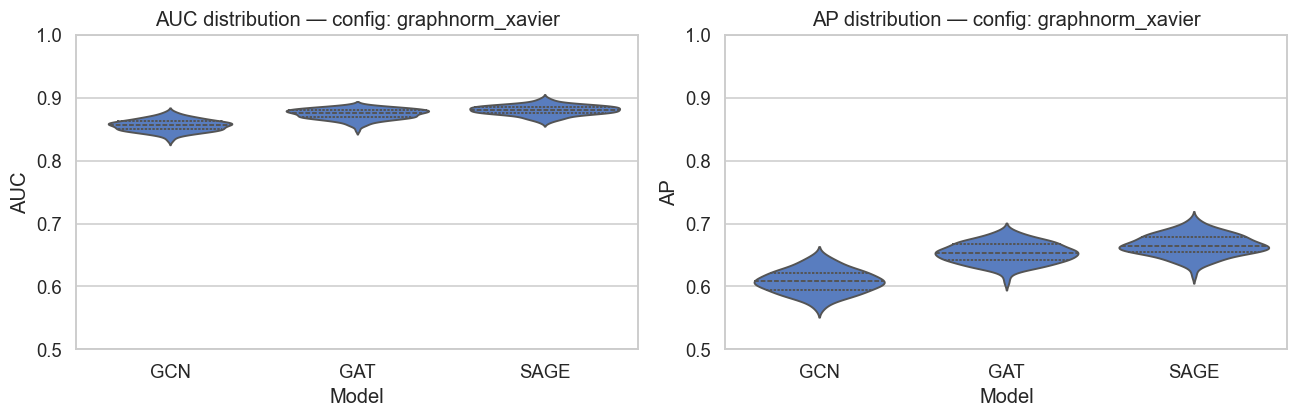

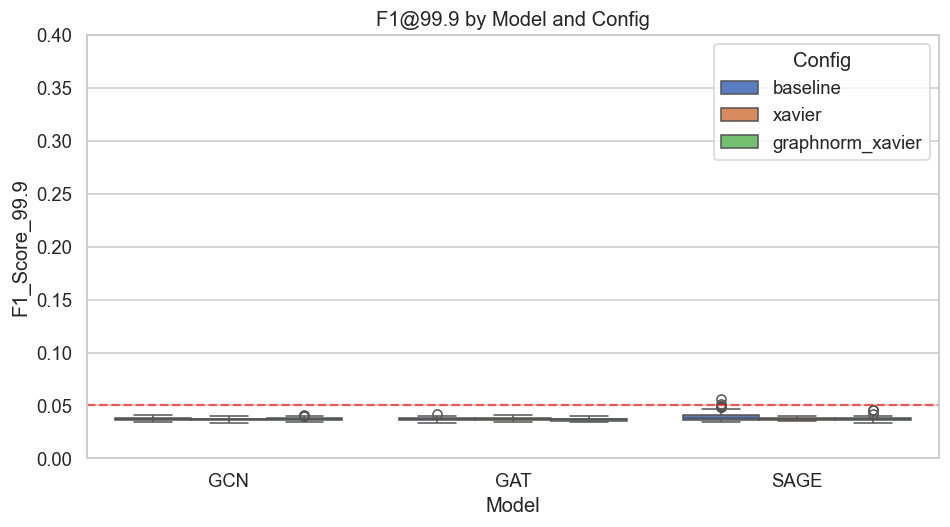

In [7]:

# b) Per-config: violin/boxplot across models for several metrics (AUC, AP, F1@99.9)
metrics_box = ["AUC","AP"]
for cfg in configs:
    subset_ti = df_ti[df_ti["Config"]==cfg]
    plt.figure(figsize=(12,4))
    for i, metric in enumerate(metrics_box):
        plt.subplot(1, len(metrics_box), i+1)
        sns.violinplot(data=subset_ti, x="Model", y=metric, inner="quartile")
        plt.title(f"{metric} distribution — config: {cfg}")
        plt.ylim(0.5,1.0)
    plt.tight_layout()
    plt.show()

# F1@99.9 boxplots (td df)
if "F1_Score_99.9" in df_td.columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df_td, x="Model", y="F1_Score_99.9", hue="Config")
    plt.title("F1@99.9 by Model and Config")
    plt.ylim(0.0, 0.4)  # zoom to the relevant small-range region if F1s are small
    plt.axhline(0.05, ls="--", color="red", alpha=0.6)
    plt.show()

In [ ]:
# c) Correlation heatmap of metrics aggregated per config+model (use pairwise columns from df_td and df_ti)
metrics_df = pd.concat([
    df_ti.set_index(["Model","Config"]),
    df_td.set_index(["Model","Config"])
], axis=1, join="inner").reset_index()
num_cols = [c for c in metrics_df.columns if metrics_df[c].dtype in [np.float64, np.int64]]
plt.figure(figsize=(10,8))
sns.heatmap(metrics_df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation heatmap of numeric metrics (AUC/AP/Prec/Recall/F1)")
plt.show()

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

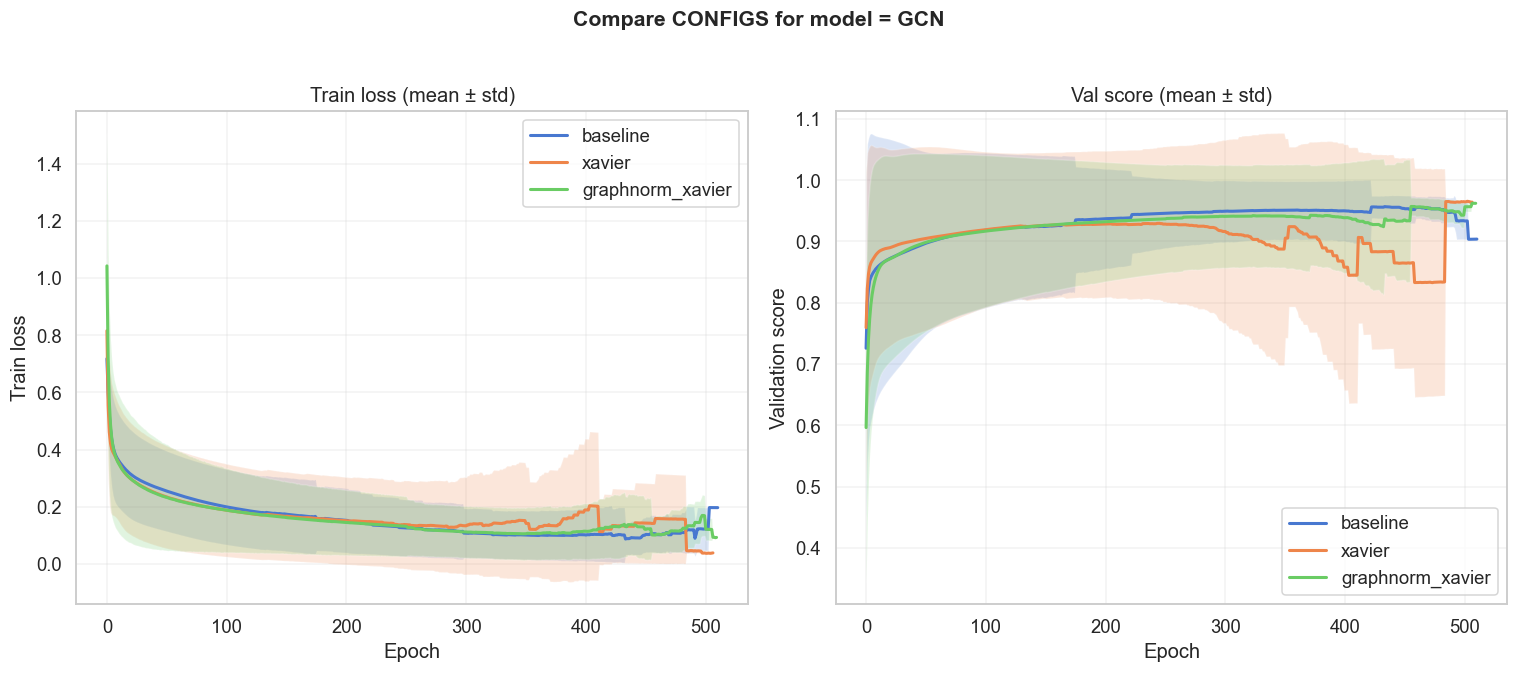

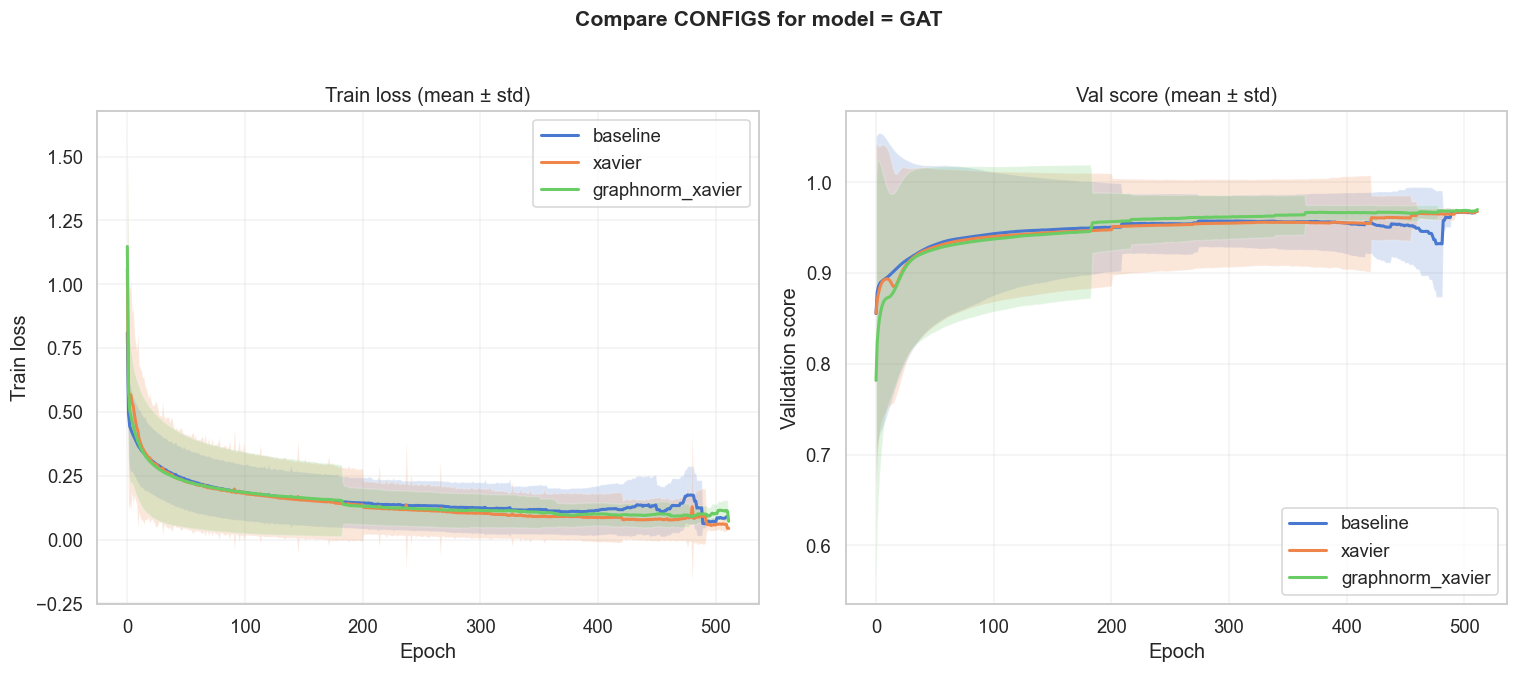

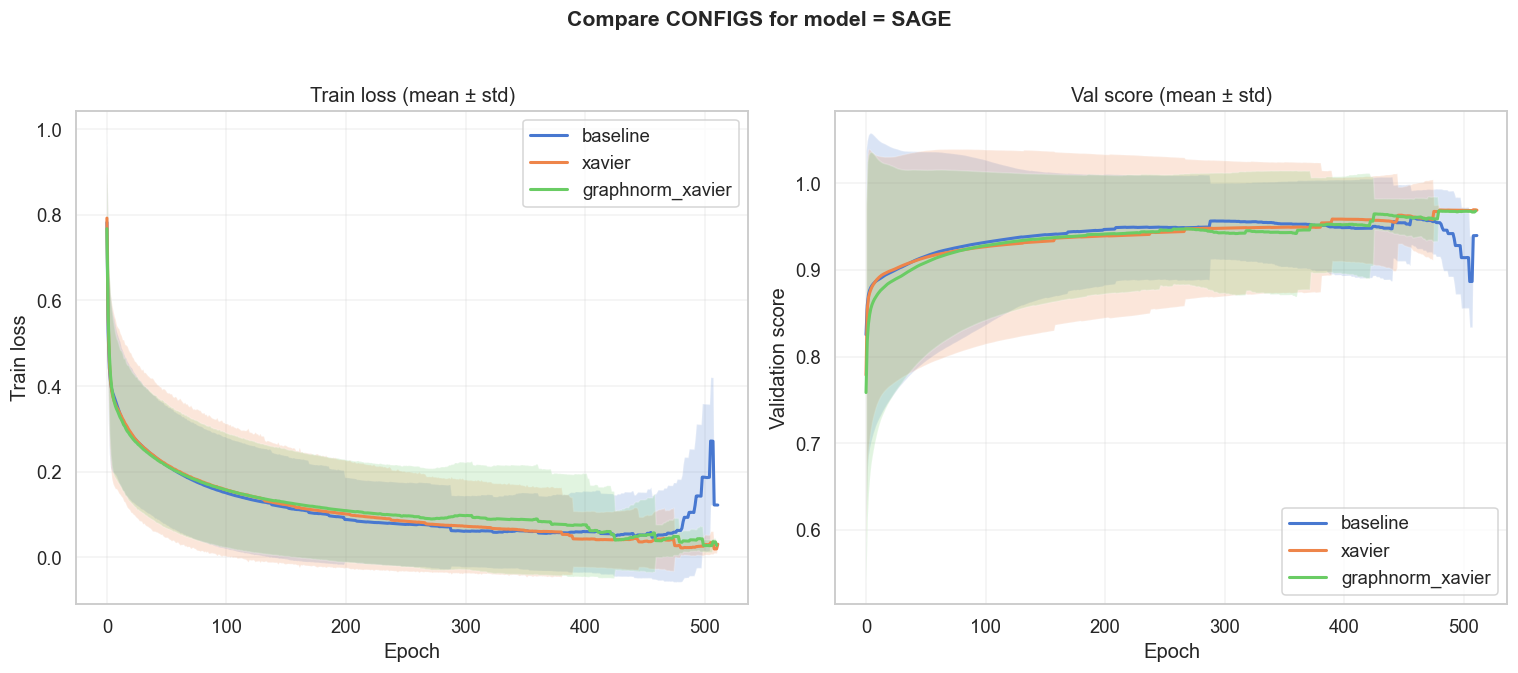

In [9]:
# ---------- 3) Compare 3 configs (each model): loss & val curve ----------
for m in models:
    plt.figure(figsize=(14,6))
    plt.suptitle(f"Compare CONFIGS for model = {m}", y=1.02, fontsize=14, weight="bold")
    ax0 = plt.subplot(1,2,1)
    for cfg in configs:
        subset = df_training[(df_training["Model"]==m) & (df_training["Config"]==cfg)]
        mean, std, length = mean_std_from_histories(subset["user_attrs_history"].tolist(), "train_loss")
        if mean is None:
            continue
        epochs = np.arange(len(mean))
        ax0.plot(epochs, mean, label=cfg, linewidth=2)
        ax0.fill_between(epochs, mean-std, mean+std, alpha=0.2)
    ax0.set_xlabel("Epoch"); ax0.set_ylabel("Train loss"); ax0.set_title("Train loss (mean ± std)")
    ax0.legend(); ax0.grid(alpha=0.25)

    ax1 = plt.subplot(1,2,2)
    for cfg in configs:
        subset = df_training[(df_training["Model"]==m) & (df_training["Config"]==cfg)]
        mean, std, length = mean_std_from_histories(subset["user_attrs_history"].tolist(), "val_score")
        if mean is None:
            mean, std, length = mean_std_from_histories(subset["user_attrs_history"].tolist(), "val_auc")
        if mean is None:
            continue
        epochs = np.arange(len(mean))
        ax1.plot(epochs, mean, label=cfg, linewidth=2)
        ax1.fill_between(epochs, mean-std, mean+std, alpha=0.2)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Validation score"); ax1.set_title("Val score (mean ± std)")
    ax1.legend(); ax1.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

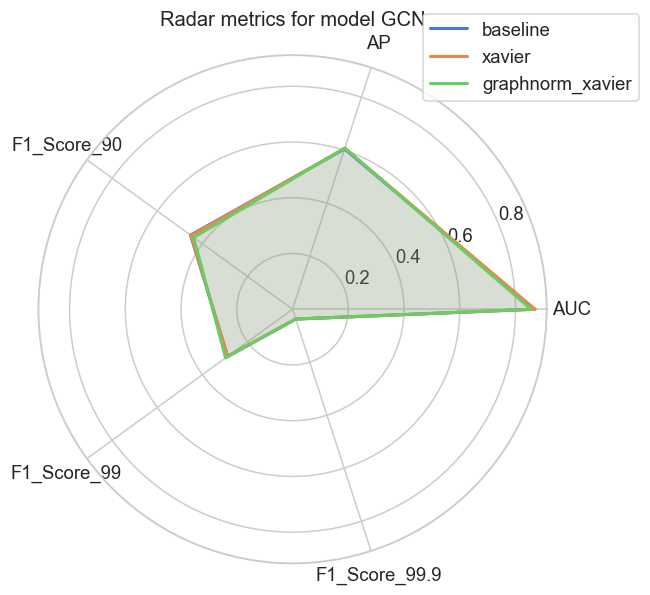

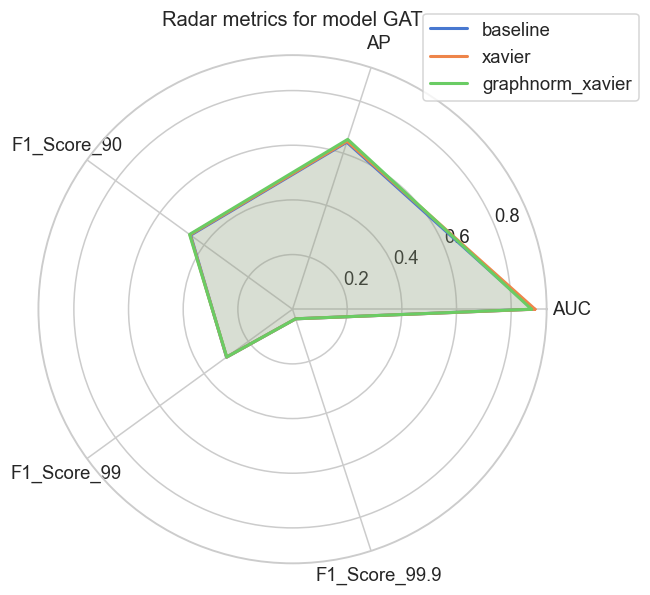

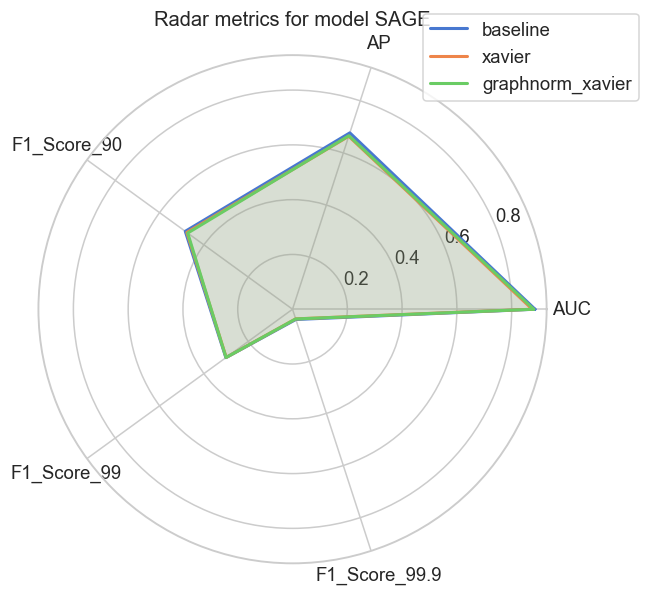

In [10]:
# ---------- 4) Creative/advanced plots ----------

# 4a: Radar chart — compare mean metrics (AUC/AP/F1@90/F1@99/F1@99.9) per model per config
radar_metrics = ["AUC","AP"]
# add f1 metrics if exist
for col in ["F1_Score_90","F1_Score_99","F1_Score_99.9"]:
    if col in df_td.columns:
        radar_metrics.append(col)

# compute means pivot
agg = {}
for (m,c), group in df_ti.groupby(["Model","Config"]):
    row = {}
    row["AUC"] = group["AUC"].mean()
    row["AP"]  = group["AP"].mean()
    # get F1 means from df_td
    td_g = df_td[(df_td["Model"]==m) & (df_td["Config"]==c)]
    for col in ["F1_Score_90","F1_Score_99","F1_Score_99.9"]:
        if col in df_td.columns:
            row[col] = td_g[col].mean() if not td_g.empty else np.nan
    agg[(m,c)] = row

# plot radar per model: each config is a trace
for m in models:
    keys = radar_metrics
    num_vars = len(keys)
    angles = np.linspace(0, 2*pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    for c in configs:
        vals = [agg.get((m,c), {}).get(k, np.nan) for k in keys]
        if all(np.isnan(vals)):
            continue
        vals = [0.0 if np.isnan(v) else v for v in vals]  # replace nan->0 for plotting
        vals += vals[:1]
        ax.plot(angles, vals, label=c, linewidth=2)
        ax.fill(angles, vals, alpha=0.12)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(keys)
    ax.set_title(f"Radar metrics for model {m}")
    ax.legend(loc="upper right", bbox_to_anchor=(1.2,1.1))
    plt.show()

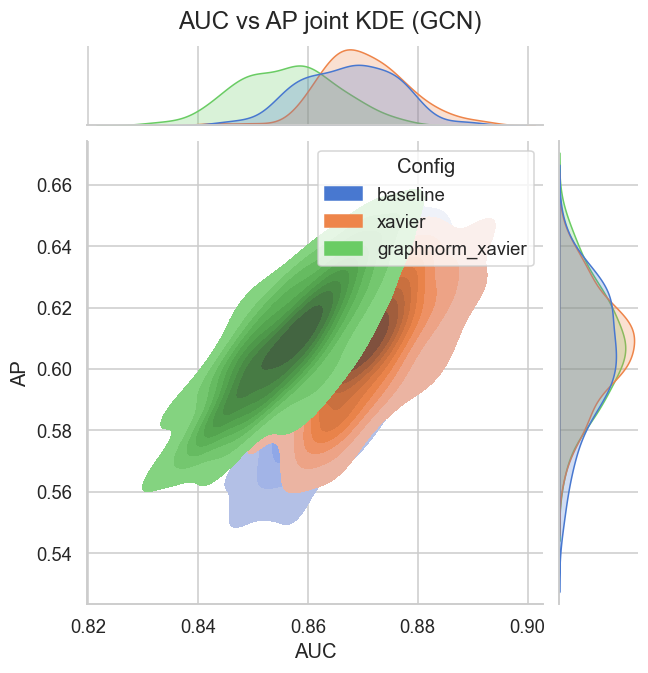

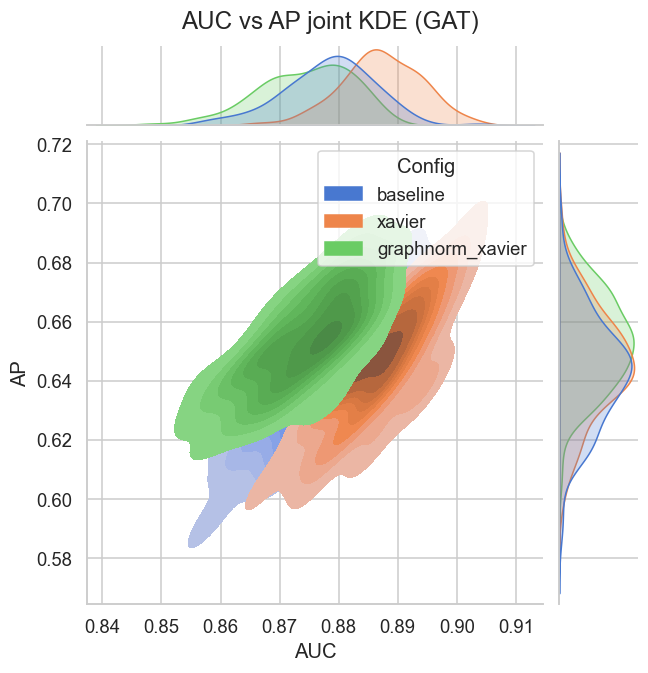

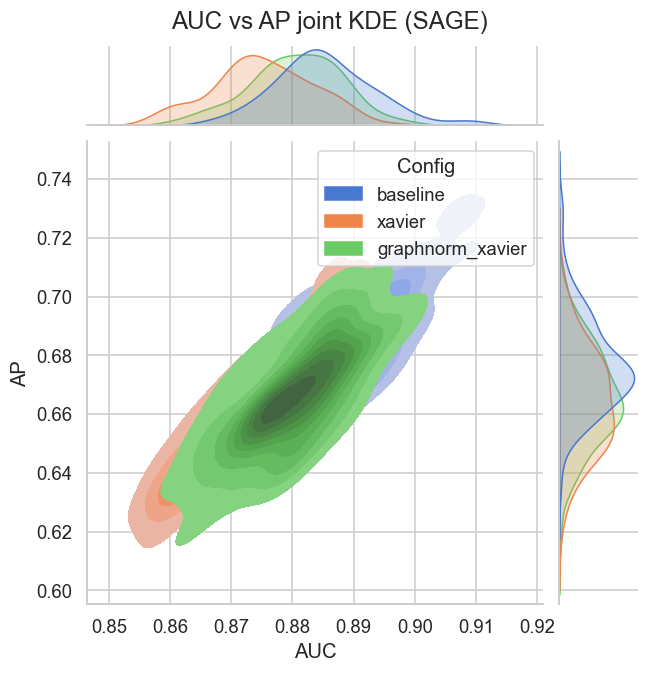

In [11]:
# 4b: Joint KDE AUC vs AP per model, hue config
for m in models:
    subset = df_ti[df_ti["Model"]==m]
    if subset.empty:
        continue
    g = sns.jointplot(data=subset, x="AUC", y="AP", hue="Config", kind="kde", height=6, fill=True)
    g.fig.suptitle(f"AUC vs AP joint KDE ({m})", y=1.02)
    plt.show()

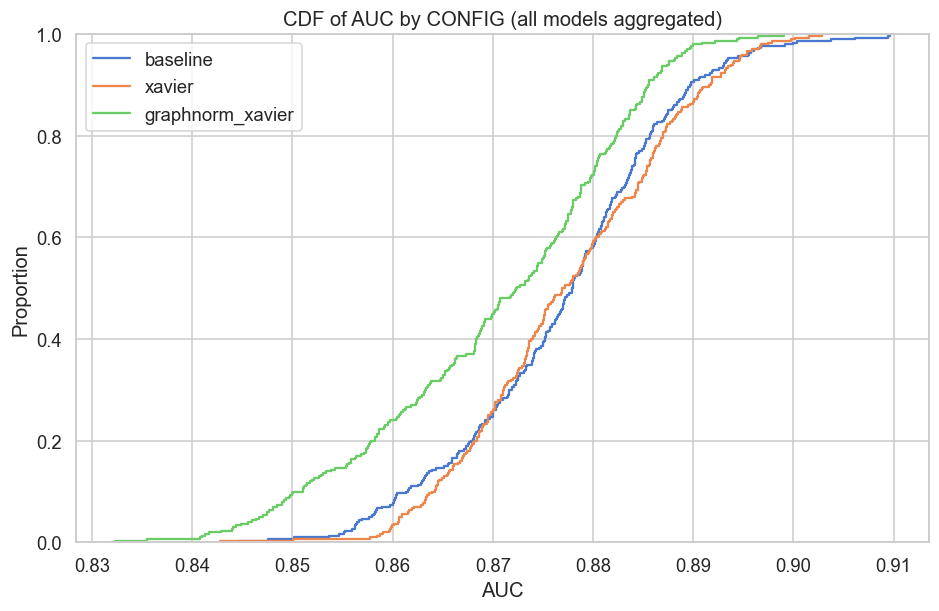

In [12]:
# 4c: CDF plots of AUC for each config & model grouped
plt.figure(figsize=(10,6))
for c in configs:
    s = df_ti[df_ti["Config"]==c]["AUC"]
    if s.empty: continue
    sns.ecdfplot(s, label=c)
plt.title("CDF of AUC by CONFIG (all models aggregated)")
plt.xlabel("AUC"); plt.legend(); plt.show()

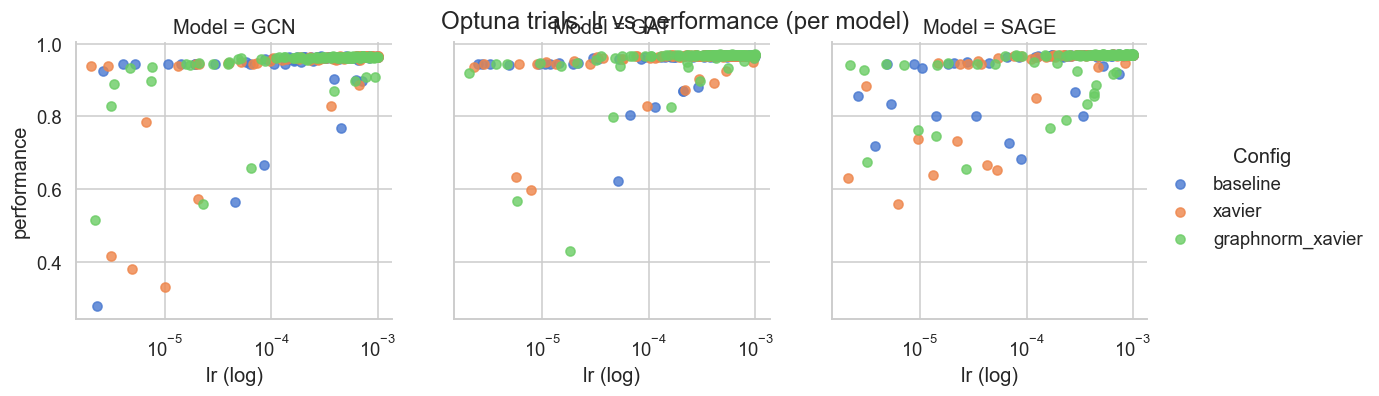

In [16]:
# 4d: Hyperparameter scatter: lr (log) vs performance, facet by Model, hue by Config
if "params_lr" in df_training.columns:
    g = sns.FacetGrid(df_training, col="Model", hue="Config", height=3.6, col_wrap=3, sharey=True)
    g.map(plt.scatter, "params_lr", "value", alpha=0.8)
    g.set(xscale="log")
    g.set_axis_labels("lr (log)", "performance")
    g.add_legend()
    plt.subplots_adjust(top=0.9); g.fig.suptitle("Optuna trials: lr vs performance (per model)")
    plt.show()

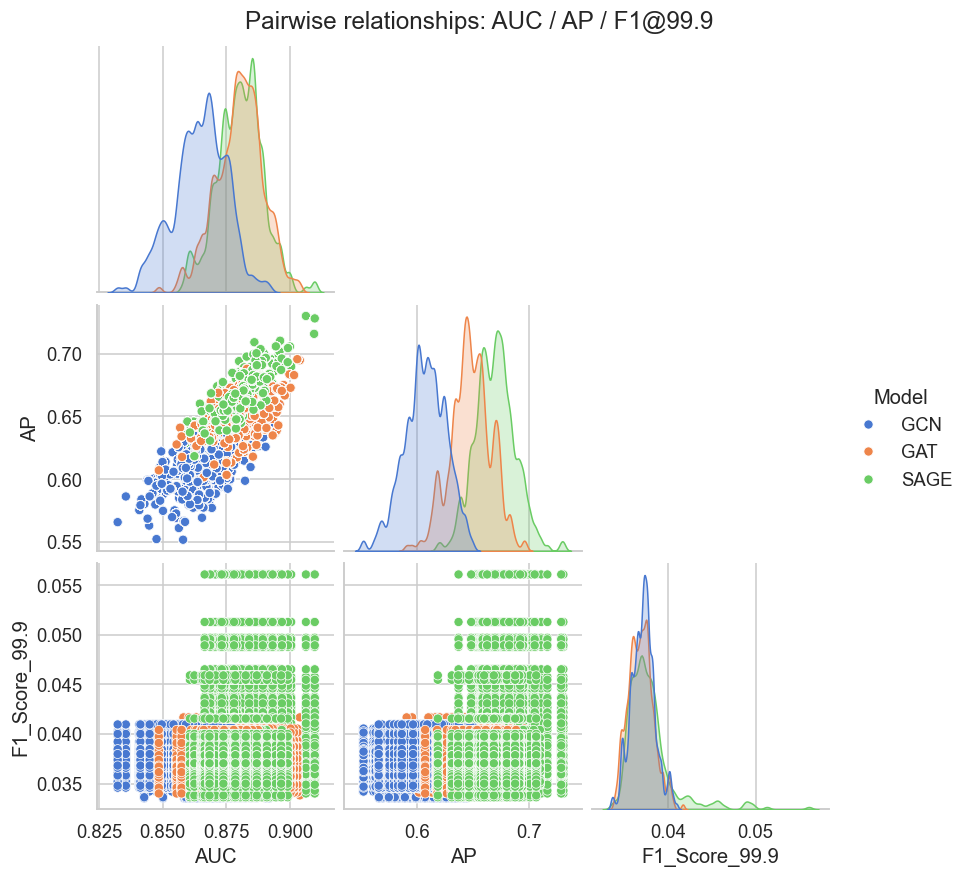

In [14]:
# 4e: Pairplot of selected summary metrics (small sample for speed)
pair_metrics = []
if "AUC" in df_ti.columns: pair_metrics.append("AUC")
if "AP" in df_ti.columns: pair_metrics.append("AP")
if "F1_Score_99.9" in df_td.columns:
    # merge a small combined dataframe
    small = df_ti.merge(df_td[["Model","Config","F1_Score_99.9"]], on=["Model","Config"], how="left")
    pair_metrics.append("F1_Score_99.9")
    sns.pairplot(small, vars=pair_metrics, hue="Model", corner=True, height=2.6)
    plt.suptitle("Pairwise relationships: AUC / AP / F1@99.9", y=1.02)
    plt.show()

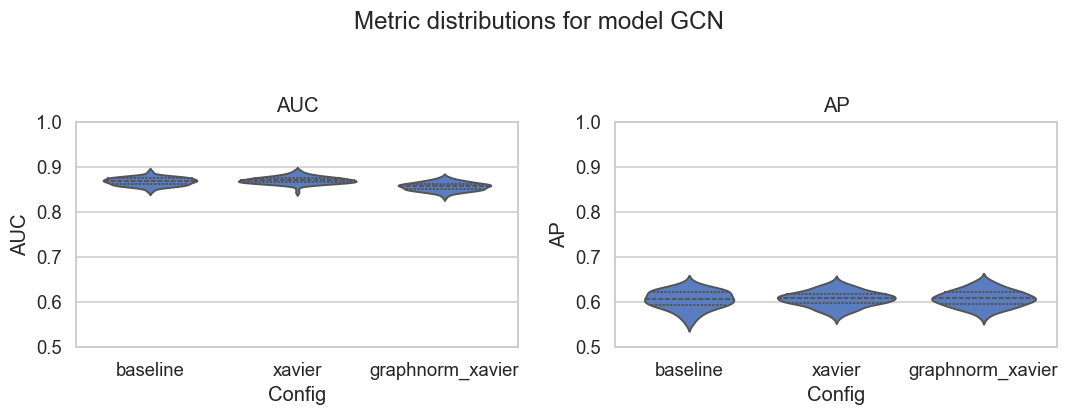

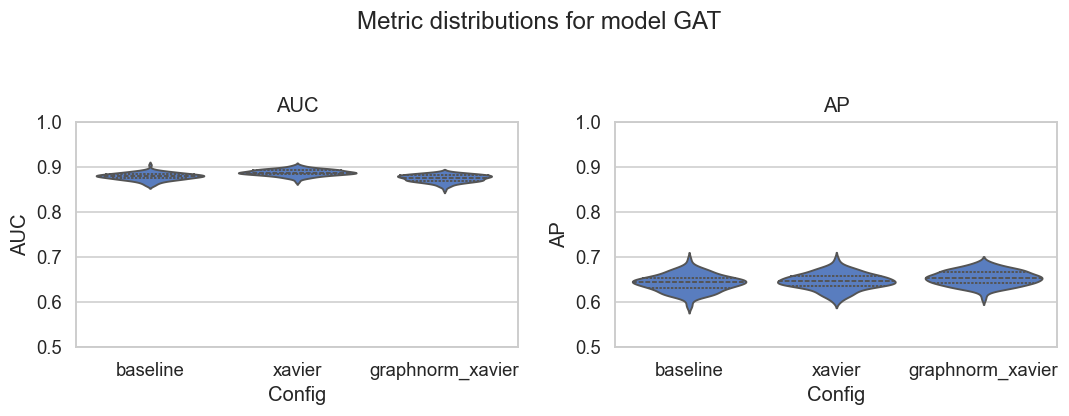

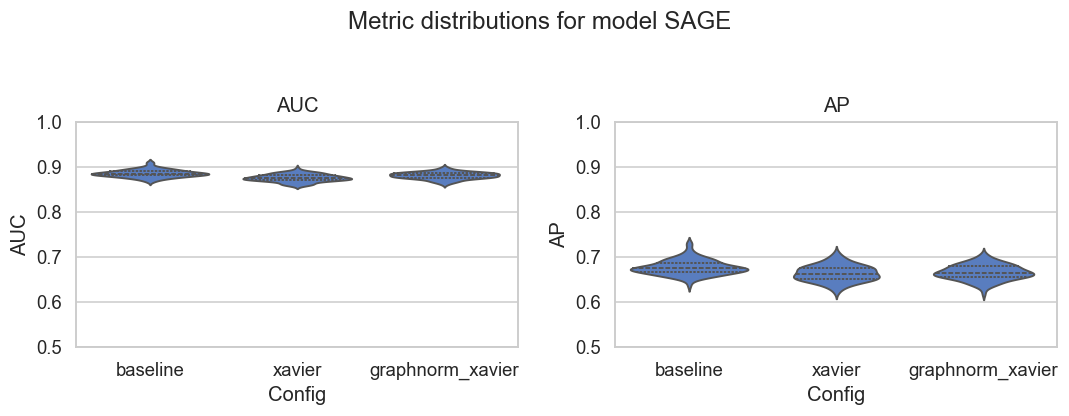

In [17]:
# 4f: Summary violin grid: per model (rows) metrics (cols) across configs
metrics_to_show = []
if "AUC" in df_ti.columns: metrics_to_show.append("AUC")
if "AP" in df_ti.columns: metrics_to_show.append("AP")
for m in models:
    subset = df_ti[df_ti["Model"]==m]
    if subset.empty: 
        continue
    plt.figure(figsize=(10, 3.6))
    plt.suptitle(f"Metric distributions for model {m}", y=1.05)
    for i, metric in enumerate(metrics_to_show):
        plt.subplot(1, len(metrics_to_show), i+1)
        sns.violinplot(data=subset, x="Config", y=metric, inner="quartile")
        plt.title(metric)
        plt.ylim(0.5,1.0)
    plt.tight_layout()
    plt.show()